# Tier 10a: tiltrotor weight models and XV-15 mass validation

Tier 9 sized a 4-rotor series hybrid to 884 kg (about 1,950 lb), well below a
Halo-class aircraft. The reference now becomes the **Bell XV-15**: a published
twin tiltrotor at 13,000 lb design gross weight, with a full group weight
statement. This notebook checks every mass model against the group it predicts.

**Sources**
- NASA TM X-62407 (1975), *XV-15 Tilt Rotor Research Aircraft Familiarization
  Document*. Used for: group weights (Nov 1974), geometry, tip speeds, V-n
  diagram, engines and drive system, and rotor modes (fig. 7.1.1).
- NASA SP-4517, appendix A, for fuselage length and cruise speed.
- W. Johnson, *NDARC Theory*, NASA/TP-2009-215402, ch. 19, for the AFDD
  rotorcraft weight equations.

**New in this tier**
- `aircraft_closure.weights.afdd`: AFDD82 blades and hub, AFDD83 gearbox and
  rotor shaft, AFDD82 drive shaft, and the AFDD82 engine section (support,
  cowling, air induction). AeroSandbox has no rotorcraft weight equations.
- `Nacelles`, `InterconnectShaft` and `FixedEquipment` mass items, plus
  retractable landing gear.
- `build_mechanical_tiltrotor`: turboshaft to gearbox to rotor, two of each.
- `examples/xv15_reference.py`: the XV-15 built from framework components.

```powershell
uv sync --group notebooks
uv run jupyter lab notebooks/tier10_xv15_reference
```

In [1]:
import sys
from dataclasses import fields, replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.weights import afdd
from examples.xv15_reference import (Xv15GroupMasses, Xv15MassFactors, Xv15Reference, calibration_factors,
                                     compare_groups, mass_turboshaft_from_power_kg, published_groups,
                                     solve_xv15_closure)

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


def close(a, b, rel=1e-9, abs_tol=1e-12):
    return abs(a - b) <= max(rel * abs(b), abs_tol)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})
reference = Xv15Reference()

## 1. AFDD equations: identities and exponents

Each wrapper converts SI to the published units (lb, ft, ft/s, hp, rpm), then
evaluates the NDARC equation unchanged. Two checks follow. First, each wrapper
must match the equation written out in English units. Second, scaling one input
must scale the result by the published exponent.

In [2]:
rotor = dict(count_rotors=2, count_blades=3, radius_m=12.5 * u.foot, chord_m=14 * u.inch,
             speed_tip_m_s=740 * u.foot, frequency_flap_per_rev=1.55)
blades_lb = 0.02606 * 2 * 3**0.6592 * 12.5**1.3371 * (14 / 12)**0.9959 * 740**0.6682 * 1.55**2.5279
hub_lb = 0.003722 * 2 * 3**0.2807 * 12.5**1.5377 * 740**0.4290 * 1.55**2.1414 * (blades_lb / 2)**0.5505
gearbox_lb = 57.72 * 3100**0.8195 * 60**0.0680 * 3**0.0663 * 20**0.0369 / 565**0.6379
check("AFDD82 blades equal the English-unit equation",
      close(afdd.mass_blades_afdd82_kg(**rotor) / u.lbm, blades_lb))
check("AFDD82 hub equals the English-unit equation",
      close(afdd.mass_hub_afdd82_kg(2, 3, 12.5 * u.foot, 740 * u.foot, 1.55, blades_lb * u.lbm) / u.lbm, hub_lb))
check("AFDD83 gearbox and rotor shaft equal the English-unit equation",
      close(afdd.mass_gearbox_rotor_shaft_afdd83_kg(3100 * u.hp, 565 * u.rpm, 20000 * u.rpm, 3, 0.6) / u.lbm, gearbox_lb))
base = afdd.mass_blades_afdd82_kg(**rotor)
for name, exponent in (("radius_m", 1.3371), ("frequency_flap_per_rev", 2.5279)):
    check(f"blade mass scales as {name}^{exponent}",
          close(afdd.mass_blades_afdd82_kg(**{**rotor, name: 2 * rotor[name]}) / base, 2**exponent))

PASS  AFDD82 blades equal the English-unit equation
PASS  AFDD82 hub equals the English-unit equation
PASS  AFDD83 gearbox and rotor shaft equal the English-unit equation
PASS  blade mass scales as radius_m^1.3371
PASS  blade mass scales as frequency_flap_per_rev^2.5279


## 2. Engine mass from AeroSandbox's turboshaft regression

`power_turboshaft(mass)` fits historical turboshafts. It is inverted with one
explicit Opti equality at the LTC1K-4K take-off rating (1,550 shp). For
comparison, the T53-L-701 weighs 688 lb dry including its nose gearbox, which
the LTC1K-4K does not have.

In [3]:
mass_engine_kg = mass_turboshaft_from_power_kg(reference.power_takeoff_engine_W)
print(f"engine: {mass_engine_kg:.1f} kg = {mass_engine_kg / u.lbm:.0f} lb, "
      f"{reference.power_takeoff_engine_W / mass_engine_kg / 1e3:.2f} kW/kg")
check("engine mass between 450 lb and the 688 lb T53-L-701 bracket", 450 < mass_engine_kg / u.lbm < 688)
check("Tier 1 default specific power (2 kW/kg) is pessimistic at this size",
      reference.power_takeoff_engine_W / mass_engine_kg > 2000.0)

engine: 252.3 kg = 556 lb, 4.58 kW/kg
PASS  engine mass between 450 lb and the 688 lb T53-L-701 bracket
PASS  Tier 1 default specific power (2 kW/kg) is pessimistic at this size


C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


## 3. Group by group at 13,000 lb

The aircraft is built from framework components at the published geometry. It
is then evaluated at the 13,000 lb design gross weight, using a 4.5 ultimate
load factor (limit 3.0, factor of safety 1.5) and a 200 kt cruise at
20,000 ft. The table maps the framework's breakdown onto the statement's
groups. Equipment (electrical, environmental, instrumentation, furnishings) is
carried at its published mass, so it is an input, not a prediction.

In [4]:
predicted = compare_groups(mass_engine_kg=mass_engine_kg)
labels = {"rotor": "rotor (AFDD82)", "wing": "wing (Raymer GA)", "tail": "tails (Raymer GA)",
          "fuselage": "fuselage (Raymer GA)", "alighting_gear": "landing gear (Raymer GA)",
          "flight_controls": "hydraulics + flight controls", "powerplant": "powerplant (ASB engine + AFDD82)",
          "transmission": "transmission (AFDD83 + AFDD82)", "equipment": "equipment (carried as given)"}
print(f"{'group':<34}{'predicted lb':>13}{'actual lb':>11}{'actual/pred':>13}")
for f in fields(Xv15GroupMasses):
    p, a = getattr(predicted, f.name), getattr(published_groups, f.name)
    print(f"{labels[f.name]:<34}{p / u.lbm:13.0f}{a / u.lbm:11.0f}{a / p:13.2f}")
print(f"{'basic empty weight':<34}{predicted.total() / u.lbm:13.0f}{published_groups.total() / u.lbm:11.0f}"
      f"{published_groups.total() / predicted.total():13.2f}")
check("published groups sum to the 9,076 lb basic empty weight", close(published_groups.total() / u.lbm, 9076))
check("drive system (AFDD83 + AFDD82) within 5 % of the transmission group",
      abs(predicted.transmission / published_groups.transmission - 1) < 0.05)
check("powerplant within 20 %", abs(predicted.powerplant / published_groups.powerplant - 1) < 0.20)

group                              predicted lb  actual lb  actual/pred
rotor (AFDD82)                             1545       1070         0.69
wing (Raymer GA)                            452        873         1.93
tails (Raymer GA)                           186        209         1.13
fuselage (Raymer GA)                        696       1442         2.07
landing gear (Raymer GA)                    585        508         0.87
hydraulics + flight controls                247        934         3.79
powerplant (ASB engine + AFDD82)           1532       1754         1.14
transmission (AFDD83 + AFDD82)             1265       1263         1.00
equipment (carried as given)               1023       1023         1.00
basic empty weight                         7530       9076         1.21
PASS  published groups sum to the 9,076 lb basic empty weight
PASS  drive system (AFDD83 + AFDD82) within 5 % of the transmission group
PASS  powerplant within 20 %


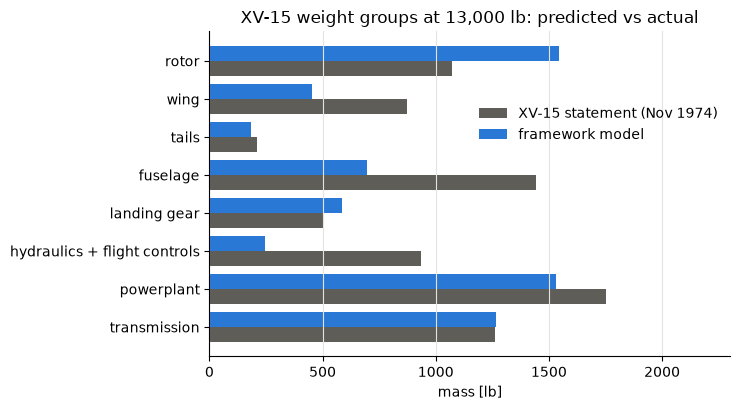

In [5]:
names = [f.name for f in fields(Xv15GroupMasses) if f.name != "equipment"]
y = np.arange(len(names))
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.barh(y + 0.2, [getattr(published_groups, n) / u.lbm for n in names], height=0.38, color=ink_muted,
        label="XV-15 statement (Nov 1974)")
ax.barh(y - 0.2, [getattr(predicted, n) / u.lbm for n in names], height=0.38, color=blue, label="framework model")
ax.set_yticks(y, [labels[n].split(" (")[0] for n in names])
ax.invert_yaxis()
ax.set(xlabel="mass [lb]", title="XV-15 weight groups at 13,000 lb: predicted vs actual")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, 2300)
ax.legend(frameon=False, loc="lower right", bbox_to_anchor=(1.0, 0.62))
plt.tight_layout()
plt.show()

**Reading the comparison**

- **The rotorcraft-specific groups do well:**
  - The AFDD drive-system equations land within 1 % of the transmission group.
  - The engine section (the regression engine plus AFDD82 support, cowling and
    air induction) is within about 13 %.
- **The fixed-wing (Raymer GA) groups are the weak link.**
  - **Wing, about half of actual.** A tiltrotor wing is sized by torsional
    stiffness, to hold whirl-flutter margins against heavy wing-tip nacelles.
    It is thick (23 %), short and heavy, and Raymer's light-aircraft equation
    sees none of that.
  - **Fuselage, about half.** The XV-15 has crash load factors, ejection
    seats and a 13,000 lb class structure.
  - **Hydraulics and flight controls, about a quarter.** Raymer's fixed-wing
    controls omit the swashplates, rotor actuators, conversion actuators and
    redundant hydraulics.
- **The rotor depends on one uncertain input,** the coning frequency
  (section 5).

These factors are design-specific, and not all of them carry over to Halo.
The XV-15's research features add weight: ejection seats, crashworthy cells,
fail-safe redundant controls and an oxygen system (TM X-62407 sec. 3). An
unmanned aircraft would not carry them.

## 4. Calibration factors and closure

The calibration factor for each group is actual divided by predicted at design
weight. Two closures are solved on the XV-15's useful load (2,434 lb of crew,
research equipment, oil and payload plus 1,490 lb of fuel), keeping its
geometry and engines:

- **Uncalibrated:** what take-off weight does the framework predict for this
  aircraft?
- **Calibrated:** this must return exactly 13,000 lb. It's a consistency check
  that the factors are applied as a fixed point of the mass build-up.

In [6]:
factors = calibration_factors(mass_engine_kg=mass_engine_kg)
for f in fields(Xv15MassFactors):
    print(f"  {f.name:<17}{getattr(factors, f.name):6.2f}")
uncalibrated = solve_xv15_closure(mass_engine_kg=mass_engine_kg)
calibrated = solve_xv15_closure(factors=factors, mass_engine_kg=mass_engine_kg)
for label, r in (("uncalibrated", uncalibrated), ("calibrated", calibrated)):
    print(f"{label:>13}: take-off {r.mass_takeoff_kg / u.lbm:7,.0f} lb   empty {r.mass_empty_kg / u.lbm:6,.0f} lb   "
          f"residual {r.closure_residual_kg:.1e} kg")
check("calibrated closure returns 13,000 lb", close(calibrated.mass_takeoff_kg / u.lbm, 13000, rel=1e-6))
check("calibrated empty weight returns 9,076 lb", close(calibrated.mass_empty_kg / u.lbm, 9076, rel=1e-6))
check("uncalibrated framework closes light (empty weight under-predicted)",
      uncalibrated.mass_takeoff_kg < reference.mass_design_kg)

  rotor              0.69
  wing               1.93
  tail               1.13
  fuselage           2.07
  alighting_gear     0.87
  flight_controls    3.79
  powerplant         1.14
  transmission       1.00


 uncalibrated: take-off  11,315 lb   empty  7,391 lb   residual -1.3e-11 kg
   calibrated: take-off  13,000 lb   empty  9,076 lb   residual 0.0e+00 kg
PASS  calibrated closure returns 13,000 lb
PASS  calibrated empty weight returns 9,076 lb
PASS  uncalibrated framework closes light (empty weight under-predicted)


## 5. Rotor mass and the coning frequency

NDARC uses the coning frequency for gimballed rotors. In TM X-62407 fig. 7.1.1,
the lowest collective mode sits at about 880 cpm at 565 rpm, roughly 1.55/rev,
but that value is read off a plot. Blade mass scales as nu^2.53 and hub mass
as nu^2.14, times a further blade-mass term. The published 1,070 lb rotor group
corresponds to nu of about 1.35, inside the range of the reading. Because the
rotor is sensitive to this input, plan 013 carries the calibrated rotor factor
rather than trusting nu.

coning frequency reproducing the 1,070 lb rotor group: 1.37/rev
PASS  rotor mass rises monotonically with coning frequency
PASS  published rotor group lies inside the 1.0-1.7/rev range


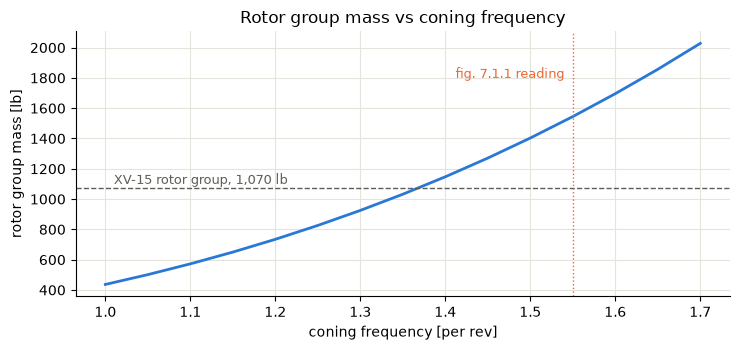

closed take-off weight over the same sweep [lb]: 10,101, 10,250, 10,428, 10,637, 10,880, 11,160, 11,480, 11,842


In [7]:
frequencies = np.linspace(1.0, 1.7, 15)
rotor_lb = [compare_groups(replace(reference, frequency_coning_per_rev=nu), mass_engine_kg=mass_engine_kg).rotor / u.lbm
            for nu in frequencies]
closed_lb = [solve_xv15_closure(replace(reference, frequency_coning_per_rev=nu),
                                mass_engine_kg=mass_engine_kg).mass_takeoff_kg / u.lbm for nu in frequencies]
nu_match = float(np.interp(published_groups.rotor / u.lbm, rotor_lb, frequencies))
print(f"coning frequency reproducing the 1,070 lb rotor group: {nu_match:.2f}/rev")
check("rotor mass rises monotonically with coning frequency", np.all(np.diff(rotor_lb) > 0))
check("published rotor group lies inside the 1.0-1.7/rev range", 1.0 < nu_match < 1.7)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(frequencies, rotor_lb, color=blue, lw=2, label="AFDD82 rotor group")
ax.axhline(published_groups.rotor / u.lbm, color=ink_muted, lw=1, ls="--")
ax.text(1.01, published_groups.rotor / u.lbm + 30, "XV-15 rotor group, 1,070 lb", color=ink_muted, fontsize=9)
ax.axvline(reference.frequency_coning_per_rev, color=orange, lw=1, ls=":")
ax.text(reference.frequency_coning_per_rev - 0.01, 1800, "fig. 7.1.1 reading", ha="right", color=orange, fontsize=9)
ax.set(xlabel="coning frequency [per rev]", ylabel="rotor group mass [lb]",
       title="Rotor group mass vs coning frequency")
plt.tight_layout()
plt.show()
print("closed take-off weight over the same sweep [lb]:", ", ".join(f"{m:,.0f}" for m in closed_lb[::2]))

## 6. What this means for the Halo-class re-baseline

- **The Tier 9 aircraft was light for two reasons.** Its requirements were
  small, and its fixed-wing mass equations under-predict rotorcraft structure.
  At XV-15 scale, the uncalibrated framework misses 19 % of empty weight, and
  closure growth lowers the result further.
- **The rotorcraft-specific models are now in place.** Rotor, drive system and
  engine section track the XV-15 (the rotor via its calibrated factor).
- **Plan 013 will apply these factors to the Halo-class aircraft:**
  - **wing:** the full factor (stiffness-sized tiltrotor wing);
  - **fuselage and flight controls:** the factors with the XV-15's
    manned-research items removed;
  - **rotor:** the calibrated factor.

  Every choice will be documented.
- **Plan 012 comes first.** It checks hover and cruise power against the
  XV-15, adding turboshaft lapse with altitude and a realistic hover figure of
  merit.

## 7. Summary and unit test suite

In [8]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

15 / 15 notebook checks passed


In [9]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 217 tests in 7.495s

OK
